In [1]:
from pathlib import Path
from collections import Counter
import yaml
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# defining paths of dataset
PROJECT_PATH=Path("..")
DATASET_PATH=PROJECT_PATH/"dataset"

DATA_YAML=DATASET_PATH/"data.yaml"

TRAIN_IMAGES=DATASET_PATH/"images"/"train"
VALID_IMAGES=DATASET_PATH/"images"/"val"
TEST_IMAGES=DATASET_PATH/"images"/"test"

TRAIN_LABELS=DATASET_PATH/"labels"/"train"
VALID_LABELS=DATASET_PATH/"labels"/"val"
TEST_LABELS=DATASET_PATH/"labels"/"test"


In [3]:
for i in DATASET_PATH.iterdir():
    print(i)

..\dataset\data.yaml
..\dataset\images
..\dataset\labels
..\dataset\models


In [4]:
# verify the image folder
image_path=DATASET_PATH/"images"
for folder in image_path.iterdir():
    print(folder)

..\dataset\images\test
..\dataset\images\train
..\dataset\images\val


In [5]:
# verify the label folder
label_path=DATASET_PATH/"labels"
for folder in label_path.iterdir():
    print(folder)

..\dataset\labels\test
..\dataset\labels\train
..\dataset\labels\val


In [6]:
# READ data.yaml
with open(DATA_YAML,'r') as file:
    data=yaml.safe_load(file)
print(data)

{'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 25, 'names': {0: 'box', 1: 'crate', 2: 'barrel', 3: 'bottle', 4: 'pallet', 5: 'rack', 6: 'bracket', 7: 'lamp', 8: 'sign', 9: 'wire', 10: 'fuse_box', 11: 'floor_decal', 12: 'fire_extinguisher', 13: 'barcode', 14: 'wall', 15: 'ceiling', 16: 'floor', 17: 'pillar', 18: 'forklift', 19: 'bucket', 20: 'cone', 21: 'cart', 22: 'emergency_board', 23: 'paper_note', 24: 'paper_shortcut'}}


In [7]:
# DATASET CONFIGURATION
print(f"Train_path:{data["train"]}")
print(f"Valid_path:{data["val"]}")
print(f"Test_path:{data["test"]}")
print(f"\nNumber of classes:{data["nc"]}")
print(f"class Names:, {data["names"]}")

Train_path:images/train
Valid_path:images/val
Test_path:images/test

Number of classes:25
class Names:, {0: 'box', 1: 'crate', 2: 'barrel', 3: 'bottle', 4: 'pallet', 5: 'rack', 6: 'bracket', 7: 'lamp', 8: 'sign', 9: 'wire', 10: 'fuse_box', 11: 'floor_decal', 12: 'fire_extinguisher', 13: 'barcode', 14: 'wall', 15: 'ceiling', 16: 'floor', 17: 'pillar', 18: 'forklift', 19: 'bucket', 20: 'cone', 21: 'cart', 22: 'emergency_board', 23: 'paper_note', 24: 'paper_shortcut'}


In [8]:
def count_files(folder, extension=None):
    if extension:
        return len(list(folder.glob(extension)))
    return len(list(folder.glob("*")))

train_images = count_files(TRAIN_IMAGES)
valid_images = count_files(VALID_IMAGES)
test_images = count_files(TEST_IMAGES)

train_labels = count_files(TRAIN_LABELS, "*.txt")
valid_labels = count_files(VALID_LABELS, "*.txt")
test_labels = count_files(TEST_LABELS, "*.txt")
print(f"Train Images: {train_images}")
print(f"Train Label: {train_labels}")
print("-"*20)
print(f"Valid Images: {valid_images}")
print(f"Valid_Labels: {valid_labels}")
print("-"*20)
print(f"Test Images: {test_images}")
print(f"Test Labels: {test_labels}")

Train Images: 4654
Train Label: 4654
--------------------
Valid Images: 1125
Valid_Labels: 1125
--------------------
Test Images: 1124
Test Labels: 1124


In [11]:
# count of images from images and labels folder
splits=["train","val","test"]
for split in splits:
    image_folder=DATASET_PATH/"images"/split
    label_folder=DATASET_PATH/"labels"/split
    image_count=len(list(image_folder.glob("*")))
    label_count=len(list(label_folder.glob("*.txt")))
    print(f'{split.upper()} set')
    print(f"Images:",{image_count})
    print(f"Label:",{label_count})
    print("-"*30)
    


TRAIN set
Images: {4654}
Label: {4654}
------------------------------
VAL set
Images: {1125}
Label: {1125}
------------------------------
TEST set
Images: {1124}
Label: {1124}
------------------------------


In [9]:
# Data Integrity Check
if train_images==train_labels:
    print("Dataset Matched")
else:
    print("Train_Dataset:  Mismatched")
if valid_images==valid_labels:
    print("Dataset Matched")
else:
    print("Valid_Dataset: Mismatched")
if test_images==test_labels:
    print("Dataset Matched")
else:
    print("Test_Dataset: Mismatched")

Dataset Matched
Dataset Matched
Dataset Matched


In [11]:
# Load the first image

import random
image_paths = list(TRAIN_IMAGES.glob("*"))
random.seed(42)      # Gives the same random images every time
sample_images = random.sample(image_paths, 5)


In [12]:
# read the image
for image_path in sample_images:
    print("=" * 70)
    print(f"Image : {image_path.name}")
    image = cv2.imread(str(image_path))
    image_copy = image.copy()
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]

# Read corresponding label file

label_path = TRAIN_LABELS / f"{image_path.stem}.txt"
with open(label_path, "r") as file:
        annotations = file.readlines()
parsed_annotations = []
for annotation in annotations:
        values = annotation.strip().split()
        parsed_annotations.append({
            "class_id": int(values[0]),
            "center_x": float(values[1]),
            "center_y": float(values[2]),
            "width": float(values[3]),
            "height": float(values[4])
        })

Image : warehouse_001235.png
Image : warehouse_000270.png
Image : warehouse_003032.png
Image : warehouse_002697.png
Image : warehouse_002453.png


In [13]:
# Drawing Bounding Box
for obj in parsed_annotations:
        class_id = obj["class_id"]
        center_x = obj["center_x"] * width
        center_y = obj["center_y"] * height
        box_width = obj["width"] * width
        box_height = obj["height"] * height
        x_min = int(center_x - box_width / 2)
        y_min = int(center_y - box_height / 2)
        x_max = int(center_x + box_width / 2)
        y_max = int(center_y + box_height / 2)
        class_name = data["names"][class_id]
        cv2.rectangle(
            image_copy,
            (x_min, y_min),
            (x_max, y_max),
            (0, 255, 0),
            2
        )
        cv2.putText(
            image_copy,
            class_name,
            (x_min, max(y_min - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

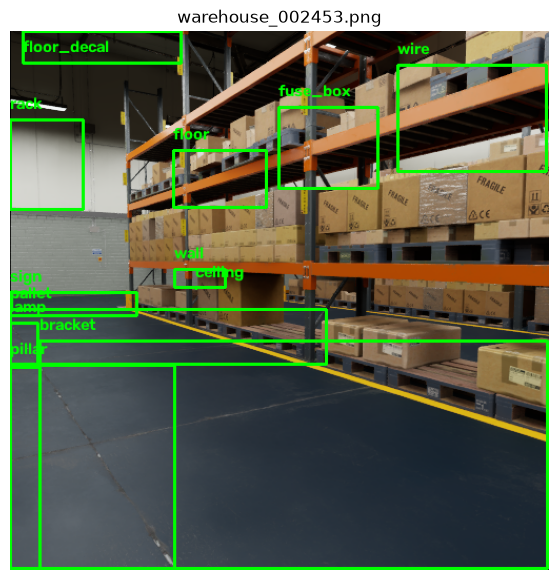

In [14]:
# DISPLAY FINAL IMAGE
final_image = cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(7,7))
plt.imshow(final_image)
plt.title(image_path.name)
plt.axis("off")
plt.show()

In [15]:
# Object Summary


for index, obj in enumerate(parsed_annotations, start=1):
    print(f"\nObject {index}")
    print(f"Class ID    : {obj['class_id']}")
    print(f"Class Name  : {data['names'][obj['class_id']]}")
    print(f"Center X    : {obj['center_x']}")
    print(f"Center Y    : {obj['center_y']}")
    print(f"Width       : {obj['width']}")
    print(f"Height      : {obj['height']}")


Object 1
Class ID    : 14
Class Name  : wall
Center X    : 0.352539
Center Y    : 0.458008
Width       : 0.091797
Height      : 0.033203

Object 2
Class ID    : 15
Class Name  : ceiling
Center X    : 0.344727
Center Y    : 0.477539
Width       : 0.001953
Height      : 0.001953

Object 3
Class ID    : 16
Class Name  : floor
Center X    : 0.388672
Center Y    : 0.273438
Width       : 0.171875
Height      : 0.105469

Object 4
Class ID    : 5
Class Name  : rack
Center X    : 0.068359
Center Y    : 0.249023
Width       : 0.136719
Height      : 0.166016

Object 5
Class ID    : 17
Class Name  : pillar
Center X    : 0.152344
Center Y    : 0.80957
Width       : 0.304688
Height      : 0.376953

Object 6
Class ID    : 6
Class Name  : bracket
Center X    : 0.526367
Center Y    : 0.787109
Width       : 0.943359
Height      : 0.421875

Object 7
Class ID    : 7
Class Name  : lamp
Center X    : 0.025391
Center Y    : 0.583984
Width       : 0.050781
Height      : 0.082031

Object 8
Class ID    : 4
Cla

In [37]:
# Note: Some bounding boxes may appear unusually large or overlap other objects. This is due to the annotations provided in the dataset, not the coordinate conversion logic. The visualization reflects the ground-truth labels exactly as stored in the YOLO annotation files.

In [16]:
# CLASS DISTRIBUTION

class_counts = Counter()
for label_file in sorted(TRAIN_LABELS.glob("*.txt")):
    with open(label_file, "r") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            class_id = int(line.split()[0])
            class_counts[class_id] += 1
print("\nObjects per Class\n")
for class_id in sorted(class_counts.keys()):
    class_name = data["names"][class_id]
    print(f"{class_name:<15} : {class_counts[class_id]}")


Objects per Class

box             : 4280
crate           : 940
barrel          : 892
bottle          : 490
pallet          : 4229
rack            : 4196
bracket         : 3618
lamp            : 3265
sign            : 4356
wire            : 2881
fuse_box        : 846
floor_decal     : 4396
fire_extinguisher : 2388
barcode         : 827
wall            : 4599
ceiling         : 2869
floor           : 4608
pillar          : 4313
forklift        : 246
bucket          : 359
cone            : 486
cart            : 341
emergency_board : 427
paper_note      : 1576
paper_shortcut  : 259


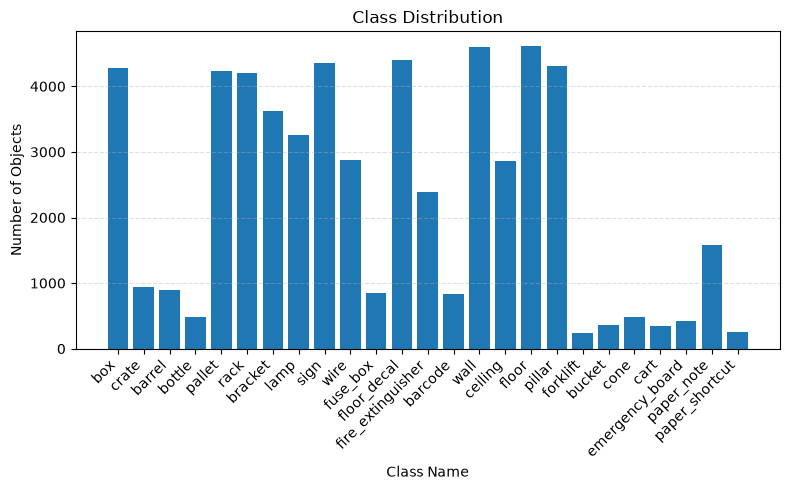

In [17]:
# Visualize class distribution
class_names = [
    data["names"][class_id]
    for class_id in sorted(class_counts.keys())
]
object_counts = [
    class_counts[class_id]
    for class_id in sorted(class_counts.keys())
]
plt.figure(figsize=(8,5))
plt.bar(class_names, object_counts)
plt.title("Class Distribution")
plt.xlabel("Class Name")
plt.ylabel("Number of Objects")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:

# DATASET STATISTICS

total_objects = sum(class_counts.values())
print(f"Total Classes : {len(data['names'])}")
print(f"Total Objects : {total_objects}")
print(f"Average Objects/Image : {total_objects/train_images:.2f}")

Total Classes : 25
Total Objects : 57687


TypeError: unsupported operand type(s) for /: 'int' and 'WindowsPath'

In [19]:

# IMAGE RESOLUTION ANALYSIS
image_shapes = []
for image_file in sorted(TRAIN_IMAGES.glob("*")):
    image = cv2.imread(str(image_file))
    image_shapes.append(image.shape[:2])
resolution_counts = Counter(image_shapes)
print("\nUnique Resolutions\n")
for resolution, count in sorted(resolution_counts.items()):
    print(f"{resolution} : {count}")
heights = [shape[0] for shape in image_shapes]
widths = [shape[1] for shape in image_shapes]
print("\nResolution Summary\n")
print(f"Minimum Height : {min(heights)}")
print(f"Maximum Height : {max(heights)}")
print(f"Minimum Width  : {min(widths)}")
print(f"Maximum Width  : {max(widths)}")
print(f"Unique Image Sizes : {len(resolution_counts)}")


Unique Resolutions

(512, 512) : 4654

Resolution Summary

Minimum Height : 512
Maximum Height : 512
Minimum Width  : 512
Maximum Width  : 512
Unique Image Sizes : 1


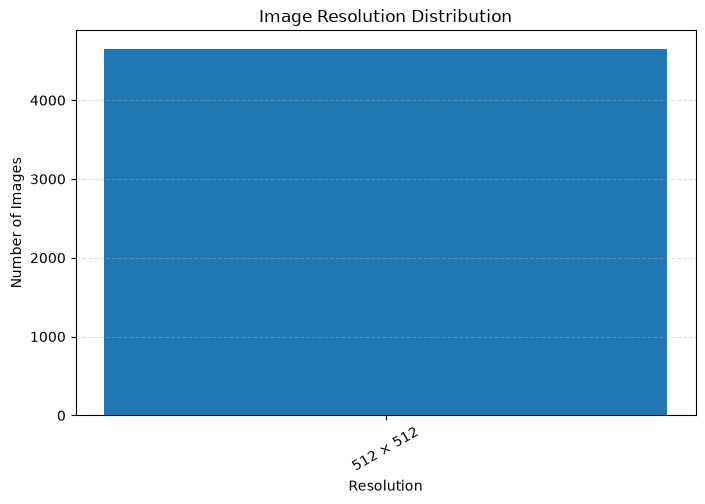

In [20]:
# Resolution distribution plot
resolution_labels = [
    f"{height} × {width}"
    for height, width in resolution_counts.keys()
]
resolution_values = list(resolution_counts.values())
plt.figure(figsize=(8,5))
plt.bar(resolution_labels, resolution_values)
plt.title("Image Resolution Distribution")
plt.xlabel("Resolution")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [21]:
# IMAGE DIMENSION SUMMARY
print(f"Average Height : {np.mean(heights):.2f}")
print(f"Average Width  : {np.mean(widths):.2f}")
print(f"Median Height  : {np.median(heights)}")
print(f"Median Width   : {np.median(widths)}")

Average Height : 512.00
Average Width  : 512.00
Median Height  : 512.0
Median Width   : 512.0


In [22]:
# EDA COMPLETED SUCCESSFULLY
print(f"✓ Total Images Analysed : {train_images}")
print(f"✓ Total Objects         : {total_objects}")
print(f"✓ Total Classes         : {len(data['names'])}")
print(f"✓ Unique Resolutions    : {len(resolution_counts)}")

✓ Total Images Analysed : ..\dataset\images\train
✓ Total Objects         : 57687
✓ Total Classes         : 25
✓ Unique Resolutions    : 1


In [23]:
# DATASET VALIDATION

image_names = {image.stem for image in TRAIN_IMAGES.glob("*")}
label_names = {label.stem for label in TRAIN_LABELS.glob("*.txt")}

In [24]:
# CHECK MISSING LABELS
missing_labels = sorted(image_names - label_names)
print("\nMissing Labels")
if len(missing_labels) == 0:
    print("✓ No Missing Labels Found")
else:
    print(f"Total Missing Labels : {len(missing_labels)}")
    for file in missing_labels:
        print(file)


Missing Labels
✓ No Missing Labels Found


In [25]:
# CHECK MISSING IMAGES
missing_images = sorted(label_names - image_names)
print("\nMissing Images")
if len(missing_images) == 0:
    print("✓ No Missing Images Found")
else:
    print(f"Total Missing Images : {len(missing_images)}")
    for file in missing_images:
        print(file)


Missing Images
✓ No Missing Images Found


In [26]:
# CHECK EMPTY ANNOTATIONS
empty_annotation_files = []
for label_file in sorted(TRAIN_LABELS.glob("*.txt")):
    with open(label_file, "r") as file:
        if file.read().strip() == "":
            empty_annotation_files.append(label_file.name)
print("\nEmpty Annotation Files")
if len(empty_annotation_files) == 0:
    print("✓ No Empty Annotation Files")
else:
    print(f"Total Empty Files : {len(empty_annotation_files)}")
    for file in empty_annotation_files:
        print(file)


Empty Annotation Files
✓ No Empty Annotation Files


In [27]:
# CHECK INVALID CLASS_ID'S

invalid_class_files = []
num_classes = data["nc"]
for label_file in sorted(TRAIN_LABELS.glob("*.txt")):
    with open(label_file, "r") as file:
        for line in file:
            if line.strip() == "":
                continue
            class_id = int(line.split()[0])
            if class_id >= num_classes:
                invalid_class_files.append(label_file.name)
print("\nInvalid Class IDs")
if len(invalid_class_files) == 0:
    print("✓ All Class IDs are Valid")
else:
    print(f"Invalid Files : {len(invalid_class_files)}")
    print(sorted(set(invalid_class_files)))


Invalid Class IDs
✓ All Class IDs are Valid


In [28]:
# CHECK BOUNDING BOX VALUES

invalid_bbox_files = []
for label_file in sorted(TRAIN_LABELS.glob("*.txt")):
    with open(label_file, "r") as file:
        for line in file:
            if line.strip() == "":
                continue
            values = list(map(float, line.split()[1:]))
            if any(value < 0 or value > 1 for value in values):
                invalid_bbox_files.append(label_file.name)
print("\nBounding Box Validation")
if len(invalid_bbox_files) == 0:
    print("✓ All Bounding Boxes are Valid")
else:
    print(f"Invalid Bounding Boxes : {len(invalid_bbox_files)}")
    print(sorted(set(invalid_bbox_files)))


Bounding Box Validation
✓ All Bounding Boxes are Valid


In [29]:
# DATASET HEALTH REPORT


health_checks = {
    "Train Image/Label Count": train_images == train_labels,
    "Validation Image/Label Count": valid_images == valid_labels,
    "Test Image/Label Count": test_images == test_labels,
    "Missing Labels": len(missing_labels) == 0,
    "Missing Images": len(missing_images) == 0,
    "Empty Annotation Files": len(empty_annotation_files) == 0,
    "Valid Class IDs": len(invalid_class_files) == 0,
    "Valid Bounding Boxes": len(invalid_bbox_files) == 0,
}
for check, status in health_checks.items():
    symbol = "✓" if status else "✗"
    print(f"{symbol} {check}")

✗ Train Image/Label Count
✓ Validation Image/Label Count
✓ Test Image/Label Count
✓ Missing Labels
✓ Missing Images
✓ Empty Annotation Files
✓ Valid Class IDs
✓ Valid Bounding Boxes


In [30]:
# FINAL DATASET SUMMARY


print(f"Training Images      : {train_images}")
print(f"Validation Images    : {valid_images}")
print(f"Test Images          : {test_images}")
print("-" * 60)
print(f"Training Labels      : {train_labels}")
print(f"Validation Labels    : {valid_labels}")
print(f"Test Labels          : {test_labels}")
print("-" * 60)
print(f"Number of Classes    : {data['nc']}")
print(f"Class Names          : {list(data['names'].values()) if isinstance(data['names'], dict) else data['names']}")
print("-" * 60)
print(f"Total Objects        : {total_objects}")
print(f"Unique Resolutions   : {len(resolution_counts)}")
print(f"Average Resolution   : {int(np.mean(heights))} × {int(np.mean(widths))}")
print("=" * 60)

Training Images      : ..\dataset\images\train
Validation Images    : 1125
Test Images          : 1124
------------------------------------------------------------
Training Labels      : 4654
Validation Labels    : 1125
Test Labels          : 1124
------------------------------------------------------------
Number of Classes    : 25
Class Names          : ['box', 'crate', 'barrel', 'bottle', 'pallet', 'rack', 'bracket', 'lamp', 'sign', 'wire', 'fuse_box', 'floor_decal', 'fire_extinguisher', 'barcode', 'wall', 'ceiling', 'floor', 'pillar', 'forklift', 'bucket', 'cone', 'cart', 'emergency_board', 'paper_note', 'paper_shortcut']
------------------------------------------------------------
Total Objects        : 57687
Unique Resolutions   : 1
Average Resolution   : 512 × 512
